# License Plate Detection with YOLO11n — Kaggle GPU run

Kaggle/GPU port of the local CPU notebook (`day7_notebook2.ipynb`). Training hyper-parameters are **identical** to the local run; the only intended difference is the hardware (`device=0`, a Kaggle GPU).

**Before running**
1. *Settings → Accelerator →* **GPU T4 x2** (or P100). Only one GPU is used (`device=0`), so the run stays comparable and avoids DDP.
2. *Settings → Internet →* **On** (needed to download `yolo11n.pt` and the plot font).
3. *Add Input →* attach the same license-plate dataset used locally. The notebook finds it automatically under `/kaggle/input`.

**Sections:** 1 Setup · 2 Dataset · 3 Train/val split · 4 Training · 5 Evaluation · 6 Inference · 7 CPU-vs-GPU comparison

## 1. Setup

In [11]:
# Optional: pin the same Ultralytics version as the local run (8.4.165) for a fair comparison.
# Set to False to keep Kaggle's preinstalled version.
PIN_ULTRALYTICS = True
if PIN_ULTRALYTICS:
    !pip install -q "ultralytics==8.4.165"

In [12]:
import os, sys, glob, json, time, random, shutil
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import ultralytics
from ultralytics import YOLO

print(f"Python Version: {sys.version.split()[0]}")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: no GPU detected. Enable it in Settings -> Accelerator, then restart the session.")
print(f"Ultralytics Version: {ultralytics.__version__}")

Python Version: 3.12.13
PyTorch Version: 2.10.0+cu128
CUDA Available: True
Device Name: Tesla T4
Ultralytics Version: 8.4.165


## 2. Dataset
Kaggle input is **read-only**, and Ultralytics needs to write label caches (and the train/val split below moves files). So the dataset is copied once to `/kaggle/working/License-Plate-Data`, and a fresh `data.yaml` with correct Kaggle paths is written.

In [13]:
INPUT_ROOT = Path("/kaggle/input")

# 1. Automatically locate the dataset directory containing train/images
candidates = sorted({p.parent.parent for p in INPUT_ROOT.rglob("images") if p.parent.name == "train"})
print("Dataset root candidates:", *candidates, sep="\n  ")
assert candidates, "No folder with train/images found under /kaggle/input - did you add the dataset via 'Add Input'?"
SRC_DIR = candidates[0]
print("Using source dataset directory:", SRC_DIR)

# 2. Copy to writable /kaggle/working directory instead of /kaggle/input
DATASET_DIR = Path("/kaggle/working/License-Plate-Data")
if not DATASET_DIR.exists():
    shutil.copytree(SRC_DIR, DATASET_DIR)

YAML_PATH = DATASET_DIR / "data.yaml"

TRAIN_IMG_DIR, TRAIN_LBL_DIR = DATASET_DIR / "train" / "images", DATASET_DIR / "train" / "labels"
VAL_IMG_DIR,   VAL_LBL_DIR   = DATASET_DIR / "val" / "images",   DATASET_DIR / "val" / "labels"
TEST_IMG_DIR,  TEST_LBL_DIR  = DATASET_DIR / "test" / "images",  DATASET_DIR / "test" / "labels"

# 3. Verify paths
for p in [DATASET_DIR, TRAIN_IMG_DIR, TRAIN_LBL_DIR, TEST_IMG_DIR, TEST_LBL_DIR]:
    print(f"[{'EXISTS' if p.exists() else 'NOT FOUND'}] {p}")

Dataset root candidates:
  /kaggle/input/notebooks/sujaymann/car-license-plate-detection/License-Plate-Data
Using source dataset directory: /kaggle/input/notebooks/sujaymann/car-license-plate-detection/License-Plate-Data
[EXISTS] /kaggle/working/License-Plate-Data
[EXISTS] /kaggle/working/License-Plate-Data/train/images
[EXISTS] /kaggle/working/License-Plate-Data/train/labels
[EXISTS] /kaggle/working/License-Plate-Data/test/images
[EXISTS] /kaggle/working/License-Plate-Data/test/labels


In [14]:
IMG_EXT = ("*.png", "*.jpg", "*.jpeg")
def list_imgs(d):
    d = Path(d)
    return sorted(f for e in IMG_EXT for f in d.glob(e)) if d.exists() else []

train_imgs, test_imgs = list_imgs(TRAIN_IMG_DIR), list_imgs(TEST_IMG_DIR)
val_imgs_orig = list_imgs(VAL_IMG_DIR)
train_lbls = list(TRAIN_LBL_DIR.glob("*.txt")); test_lbls = list(TEST_LBL_DIR.glob("*.txt"))

print("=== Dataset Summary (before the 80/20 re-split) ===")
print(f"Train Images: {len(train_imgs)}  (local run: 277)   Labels: {len(train_lbls)}")
print(f"Val   Images: {len(val_imgs_orig)}  (local run: 69, from the dataset itself)")
print(f"Test  Images: {len(test_imgs)}  (local run: 87)   Labels: {len(test_lbls)}")

if train_lbls:
    s = train_lbls[0]
    print(f"\nSample annotation ({s.name}): {s.read_text().strip()}")

# Class names from the original yaml if present (local run: nc=1)
import yaml
names = {0: "License_Plate"}
if (SRC_DIR / "data.yaml").exists():
    y = yaml.safe_load((SRC_DIR / "data.yaml").read_text())
    print("Original data.yaml:", y)
    n = y.get("names")
    if n: names = dict(enumerate(n)) if isinstance(n, list) else {int(k): v for k, v in n.items()}
print("Class names:", names)

=== Dataset Summary (before the 80/20 re-split) ===
Train Images: 346  (local run: 277)   Labels: 346
Val   Images: 0  (local run: 69, from the dataset itself)
Test  Images: 87  (local run: 87)   Labels: 87

Sample annotation (Cars302.txt): 0 0.647 0.5277777777777778 0.40599999999999997 0.2179487179487179
Original data.yaml: {'names': {0: 'license_plate'}, 'nc': 1, 'train': '/kaggle/working/License-Plate-Data/train', 'val': '/kaggle/working/License-Plate-Data/test'}
Class names: {0: 'license_plate'}


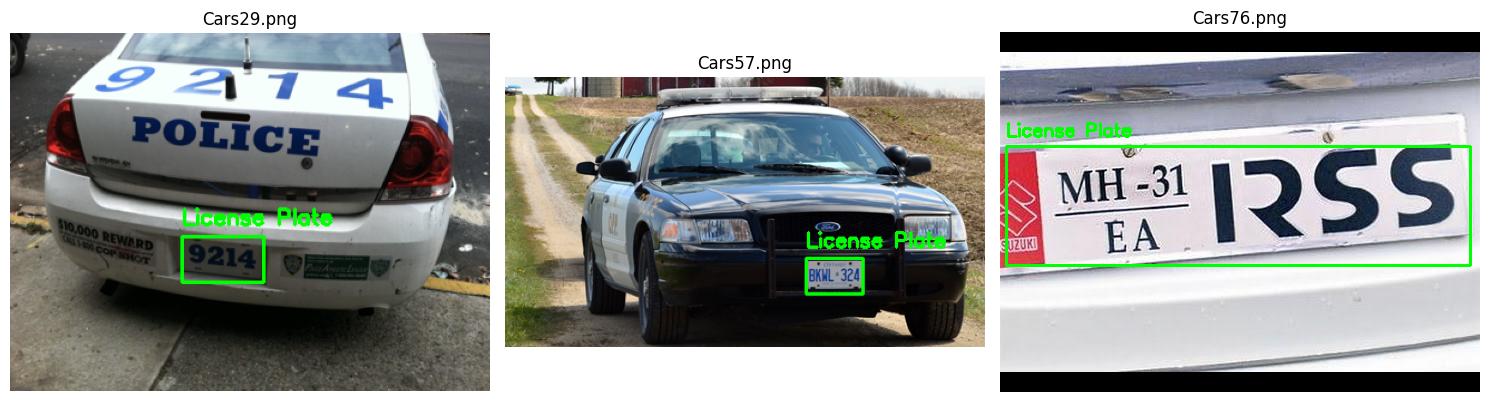

In [15]:
def draw_yolo_bbox(img_path, label_path):
    image = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h_img, w_img, _ = image.shape
    if label_path.exists():
        for line in label_path.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) == 5:
                cls, xc, yc, w, h = map(float, parts)
                x1, y1 = int((xc - w/2) * w_img), int((yc - h/2) * h_img)
                x2, y2 = int((xc + w/2) * w_img), int((yc + h/2) * h_img)
                cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(image, "License Plate", (x1, max(y1 - 10, 15)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    return image

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img_p in zip(axes, random.sample(train_imgs, 3)):
    ax.imshow(draw_yolo_bbox(img_p, TRAIN_LBL_DIR / f"{img_p.stem}.txt"))
    ax.set_title(img_p.name); ax.axis("off")
plt.tight_layout(); plt.show()

## 3. Train / validation split
Same logic as the local notebook: move a random 20 % of `train/` into `val/` with `random.seed(42)`.
The file list is **sorted** first so the result is deterministic on Linux. (Local `glob` order on Windows differs, so the exact 55 files may not match the local run, but the sizes will: 222 train / 124 val.)

The cell is guarded: it only runs once, so re-running the notebook will not move another 20 %.

In [16]:
VAL_IMG_DIR.mkdir(parents=True, exist_ok=True)
VAL_LBL_DIR.mkdir(parents=True, exist_ok=True)

FLAG = DATASET_DIR / ".split_done"
if not FLAG.exists():
    all_train_imgs = list_imgs(TRAIN_IMG_DIR)
    val_count = int(len(all_train_imgs) * 0.2)
    random.seed(42)
    val_selected = random.sample(all_train_imgs, val_count)
    for img_path in val_selected:
        lbl_path = TRAIN_LBL_DIR / f"{img_path.stem}.txt"
        shutil.move(str(img_path), str(VAL_IMG_DIR / img_path.name))
        if lbl_path.exists():
            shutil.move(str(lbl_path), str(VAL_LBL_DIR / lbl_path.name))
    FLAG.touch()
    print(f"Moved {len(val_selected)} images and labels to validation set.")
else:
    print("Split already done, skipping.")

print(f"Training images:   {len(list_imgs(TRAIN_IMG_DIR))}   (local run: 222)")
print(f"Validation images: {len(list_imgs(VAL_IMG_DIR))}   (local run: 124)")
print(f"Test images:       {len(list_imgs(TEST_IMG_DIR))}   (local run: 87)")

# Fresh data.yaml with absolute Kaggle paths (test split included for final evaluation)
data_cfg = {"path": str(DATASET_DIR), "train": "train/images", "val": "val/images",
            "test": "test/images", "nc": len(names), "names": names}
YAML_PATH.write_text(yaml.safe_dump(data_cfg, sort_keys=False))
print(YAML_PATH.read_text())

Moved 69 images and labels to validation set.
Training images:   277   (local run: 222)
Validation images: 69   (local run: 124)
Test images:       87   (local run: 87)
path: /kaggle/working/License-Plate-Data
train: train/images
val: val/images
test: test/images
nc: 1
names:
  0: license_plate



## 4. Training
Parameters copied verbatim from the local run: `epochs=20, imgsz=640, batch=16, patience=10, workers=4, seed=42`, starting from `yolo11n.pt`.
The only addition is `device=0` (GPU). Wall-clock time is recorded for the comparison at the end (local CPU run: **0.682 h ≈ 2455 s**).

In [25]:
DEVICE = 0 if torch.cuda.is_available() else "cpu"
RUNS_DIR = DATASET_DIR / "runs"
RUN_NAME = "license_plate_run"

model = YOLO("yolo11n.pt")

t0 = time.time()
results = model.train(
    data=str(YAML_PATH),
    epochs=20,
    imgsz=640,
    batch=16,
    patience=10,
    workers=0,
    project=str(RUNS_DIR),
    name=RUN_NAME,
    exist_ok=True,
    seed=42,
    device=DEVICE,        # <-- only change vs. the local CPU run
)
TRAIN_SECONDS = time.time() - t0

CHECKPOINT_PATH = RUNS_DIR / RUN_NAME / "weights" / "best.pt"
print(f"\nTraining complete in {TRAIN_SECONDS/3600:.3f} h ({TRAIN_SECONDS:.0f} s)")
print(f"Best weights: {CHECKPOINT_PATH}")

Ultralytics 8.4.165 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/License-Plate-Data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=license_plate_run, nbs=64, nms=None, opset=No

### Training curves

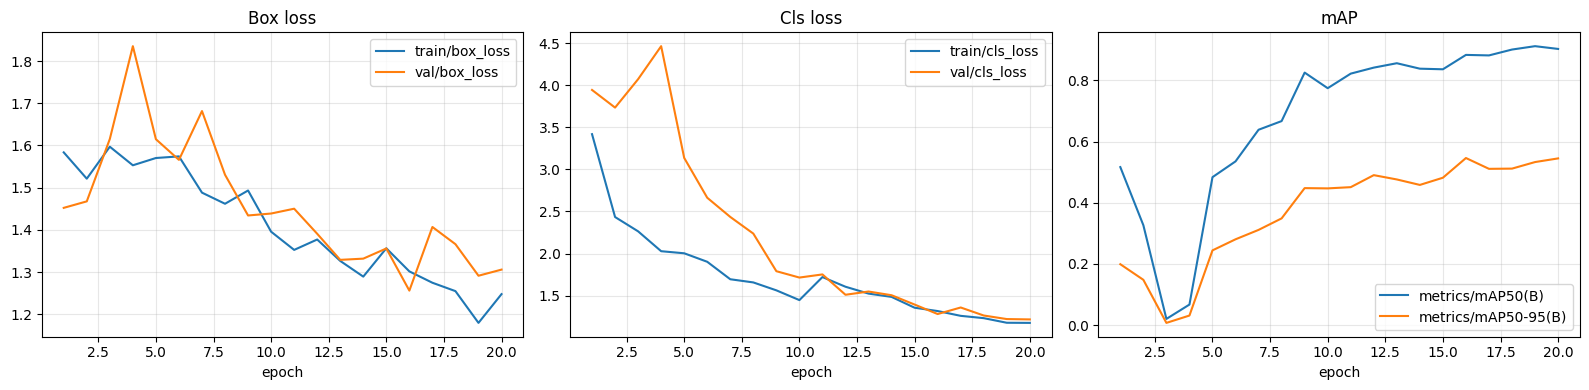

In [26]:
run_dir = RUNS_DIR / RUN_NAME
df = pd.read_csv(run_dir / "results.csv"); df.columns = [c.strip() for c in df.columns]
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for c in ["train/box_loss", "val/box_loss"]: ax[0].plot(df["epoch"], df[c], label=c)
for c in ["train/cls_loss", "val/cls_loss"]: ax[1].plot(df["epoch"], df[c], label=c)
for c in ["metrics/mAP50(B)", "metrics/mAP50-95(B)"]: ax[2].plot(df["epoch"], df[c], label=c)
for a, t in zip(ax, ["Box loss", "Cls loss", "mAP"]): a.set_title(t); a.set_xlabel("epoch"); a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 5. Evaluation
`best.pt` is evaluated on the **validation** split (directly comparable with the numbers printed by the local run) and on the held-out **test** split (87 images, which the local notebook never evaluated).

In [28]:
best = YOLO(CHECKPOINT_PATH)

def evaluate(split):
    m = best.val(data=str(YAML_PATH), split=split, imgsz=640, batch=16, device=DEVICE,
                 project=str(RUNS_DIR), name=f"eval_{split}", exist_ok=True, plots=True)
    return {"split": split, "precision": m.box.mp, "recall": m.box.mr,
            "mAP50": m.box.map50, "mAP50-95": m.box.map,
            "preprocess_ms": m.speed["preprocess"], "inference_ms": m.speed["inference"],
            "postprocess_ms": m.speed["postprocess"]}

eval_val  = evaluate("val")
eval_test = evaluate("test")
pd.DataFrame([eval_val, eval_test]).set_index("split").round(4)

Ultralytics 8.4.165 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3433.2±1591.7 MB/s, size: 443.1 KB)
val: Scanning /kaggle/working/License-Plate-Data/val/labels.cache... 69 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 69/69 15.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 3.2it/s 1.6s0.5s
                   all         69         69      0.809      0.858      0.883      0.544
Speed: 3.6ms preprocess, 5.6ms inference, 0.0ms loss, 4.5ms postprocess per image
Results saved to /kaggle/working/License-Plate-Data/runs/eval_val
Ultralytics 8.4.165 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3477.3±419.0 MB/s, 

,precision,recall,mAP50,mAP50-95,preprocess_ms,inference_ms,postprocess_ms
split,,,,,,,
val,0.8088,0.8582,0.8835,0.5439,3.5992,5.5985,4.5176
test,0.8670,0.8046,0.8616,0.4858,1.8932,5.4186,2.9586


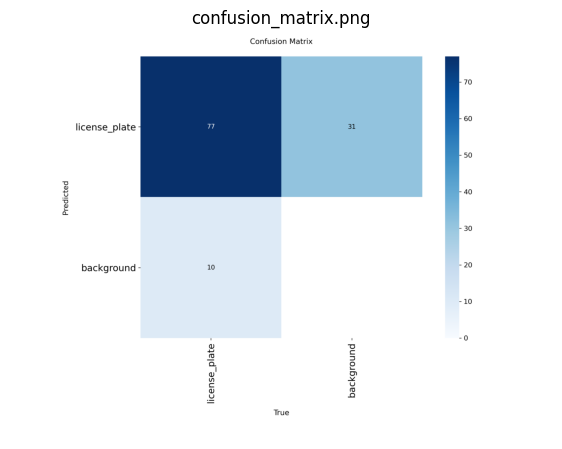

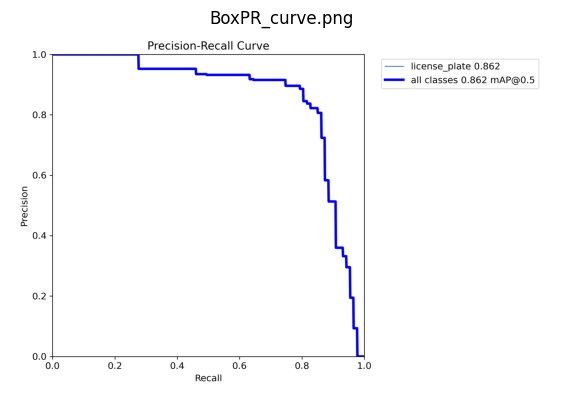

In [29]:
# Confusion matrix & PR curve from the test evaluation
for f in ["confusion_matrix.png", "BoxPR_curve.png"]:
    p = RUNS_DIR / "eval_test" / f
    if p.exists():
        plt.figure(figsize=(7, 6)); plt.imshow(Image.open(p)); plt.axis("off"); plt.title(f); plt.show()

## 6. Inference on the test set

Images with >=1 detection: 79/87


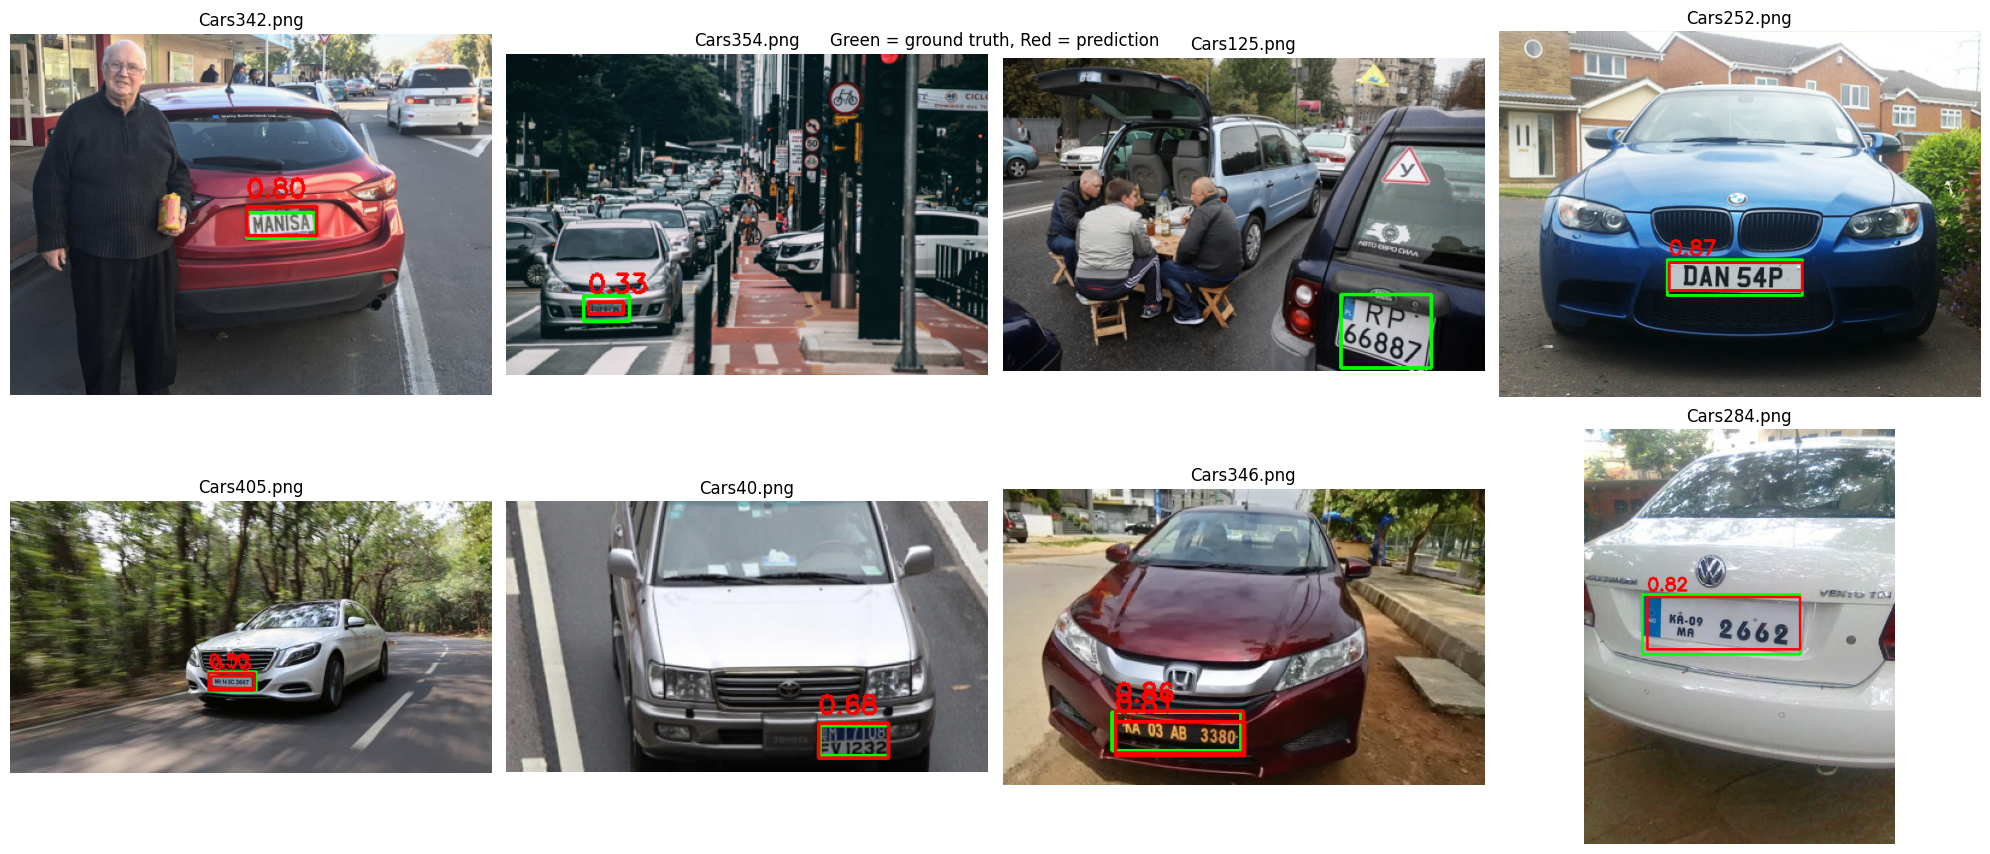

In [31]:
test_imgs = list_imgs(TEST_IMG_DIR)
pred_results = best.predict(source=[str(p) for p in test_imgs], imgsz=640, conf=0.25,
                            device=DEVICE, save=False, verbose=False)

n_with = sum(len(r.boxes) > 0 for r in pred_results)
print(f"Images with >=1 detection: {n_with}/{len(pred_results)}")

# Ground truth (green) vs. prediction (red) for 8 random test images
def gt_boxes(img_path, shape):
    h, w = shape[:2]; out = []
    lbl = TEST_LBL_DIR / f"{img_path.stem}.txt"
    if lbl.exists():
        for line in lbl.read_text().splitlines():
            p = line.split()
            if len(p) == 5:
                _, xc, yc, bw, bh = map(float, p)
                out.append((int((xc-bw/2)*w), int((yc-bh/2)*h), int((xc+bw/2)*w), int((yc+bh/2)*h)))
    return out

random.seed(0)
picks = random.sample(range(len(test_imgs)), 8)
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, i in zip(axes.ravel(), picks):
    r = pred_results[i]; img = cv2.cvtColor(cv2.imread(str(test_imgs[i])), cv2.COLOR_BGR2RGB)
    for x1, y1, x2, y2 in gt_boxes(test_imgs[i], img.shape):
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    for b in r.boxes:
        x1, y1, x2, y2 = map(int, b.xyxy[0].tolist())
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(img, f"{float(b.conf):.2f}", (x1, max(y1-8, 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
    ax.imshow(img); ax.set_title(test_imgs[i].name); ax.axis("off")
fig.suptitle("Green = ground truth, Red = prediction", y=0.92)
plt.tight_layout(); plt.show()

In [32]:
# Per-image inference latency, one image at a time (batch=1), after a GPU warm-up
for _ in range(5): best.predict(str(test_imgs[0]), imgsz=640, device=DEVICE, verbose=False)
lat = []
for p in test_imgs:
    r = best.predict(str(p), imgsz=640, conf=0.25, device=DEVICE, verbose=False)[0]
    lat.append(sum(r.speed.values()))          # preprocess + inference + postprocess (ms)
lat = np.array(lat)
print(f"Latency per image: mean {lat.mean():.1f} ms | median {np.median(lat):.1f} ms | p95 {np.percentile(lat,95):.1f} ms "
      f"-> {1000/lat.mean():.1f} FPS")

Latency per image: mean 10.0 ms | median 10.0 ms | p95 11.1 ms -> 100.4 FPS


## 7. CPU vs GPU comparison
Local CPU numbers (Intel i7-12700, from the local run log) are hard-coded below; the Kaggle numbers come from this notebook.
The results are also saved to `/kaggle/working/kaggle_gpu_results.json` so they can be downloaded from the *Output* tab.

In [34]:
LOCAL = {  # from day7_notebook2.ipynb (best.pt on the 124-image validation split)
    "hardware": "Intel i7-12700 (CPU)", "train_time_s": 0.682 * 3600,
    "precision": 0.883, "recall": 0.850, "mAP50": 0.914, "mAP50-95": 0.549,
    "inference_ms_per_img": 45.0,
}
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
KAGGLE = {
    "hardware": gpu_name, "train_time_s": TRAIN_SECONDS,
    "precision": eval_val["precision"], "recall": eval_val["recall"],
    "mAP50": eval_val["mAP50"], "mAP50-95": eval_val["mAP50-95"],
    "inference_ms_per_img": eval_val["inference_ms"],
}
cmp = pd.DataFrame({"Local CPU": LOCAL, "Kaggle GPU": KAGGLE})
print(cmp.to_string())
print(f"\nTraining speed-up:  {LOCAL['train_time_s']/KAGGLE['train_time_s']:.1f}x")
print(f"Inference speed-up: {LOCAL['inference_ms_per_img']/KAGGLE['inference_ms_per_img']:.1f}x")
print(f"Held-out TEST (Kaggle GPU): mAP50={eval_test['mAP50']:.3f}, mAP50-95={eval_test['mAP50-95']:.3f}")

json.dump({"local_cpu": LOCAL, "kaggle_gpu": KAGGLE, "kaggle_test": eval_test,
           "latency_ms_mean_bs1": float(lat.mean())},
          open("/kaggle/working/kaggle_gpu_results.json", "w"), indent=2)

                                 Local CPU  Kaggle GPU
hardware              Intel i7-12700 (CPU)    Tesla T4
train_time_s                        2455.2  172.091522
precision                            0.883     0.80877
recall                                0.85    0.858152
mAP50                                0.914    0.883461
mAP50-95                             0.549    0.543934
inference_ms_per_img                  45.0    5.598529

Training speed-up:  14.3x
Inference speed-up: 8.0x
Held-out TEST (Kaggle GPU): mAP50=0.862, mAP50-95=0.486


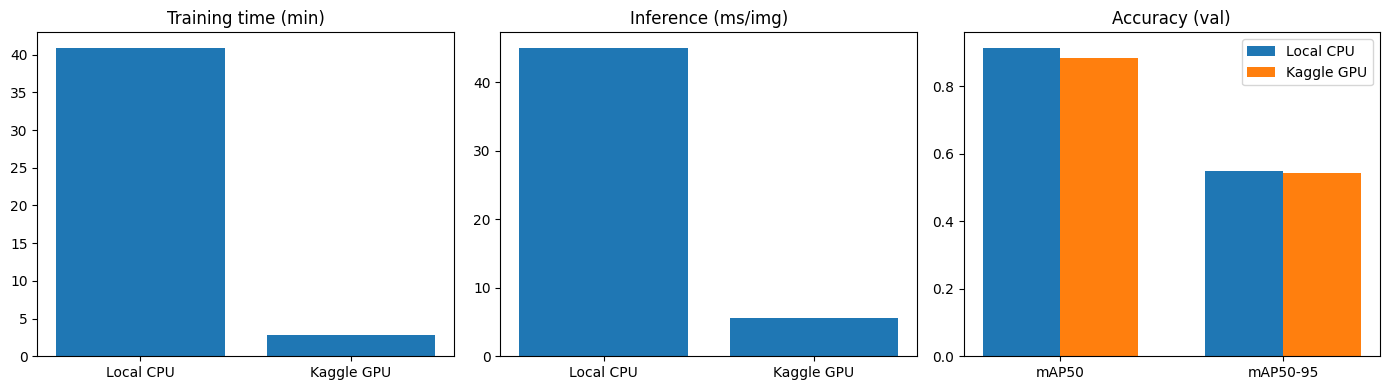

In [35]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
labels = ["Local CPU", "Kaggle GPU"]
ax[0].bar(labels, [LOCAL["train_time_s"]/60, KAGGLE["train_time_s"]/60]); ax[0].set_title("Training time (min)")
ax[1].bar(labels, [LOCAL["inference_ms_per_img"], KAGGLE["inference_ms_per_img"]]); ax[1].set_title("Inference (ms/img)")
w = 0.35; x = np.arange(2)
ax[2].bar(x-w/2, [LOCAL["mAP50"], LOCAL["mAP50-95"]], w, label="Local CPU")
ax[2].bar(x+w/2, [KAGGLE["mAP50"], KAGGLE["mAP50-95"]], w, label="Kaggle GPU")
ax[2].set_xticks(x); ax[2].set_xticklabels(["mAP50", "mAP50-95"]); ax[2].set_title("Accuracy (val)"); ax[2].legend()
plt.tight_layout(); plt.show()